In [ ]:
!pip install PyWavelets torchmetrics matplotlib torch-fidelity
!pip install ptwt==0.1.8 --no-deps
!pip install pytorchfwd --no-deps

  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached torch_fidelity-0.4.0-py3-none-any.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.1 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance
from torch.utils.data import DataLoader

import os
import shutil
import subprocess
import re
import torch
from torchvision.utils import save_image

In [ ]:
# download and format images

transform = T.Compose([
    # T.Resize((256, 256)),
    T.ToTensor(),
    T.Lambda(lambda x: (x*255).to(torch.uint8))
])

# download cifar-10
dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

real_images, _ = next(iter(dataloader))

base_generated_images = real_images.clone()

In [ ]:
# setup gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_images = real_images.to(device)
base_generated_images = base_generated_images.to(device)

In [ ]:
# function to utilize fwd's CLI tool
# https://pypi.org/project/pytorchfwd/
def compute_fwd(real_batch, fake_batch):
    real_dir = '/tmp/fwd_real'
    fake_dir = '/tmp/fwd_fake'
    os.makedirs(real_dir, exist_ok=True)
    os.makedirs(fake_dir, exist_ok=True)

    # save images to directory for the CLI tool
    for i in range(len(real_batch)):
        save_image(real_batch[i].float() / 255.0, f'{real_dir}/{i}.png')
        save_image(fake_batch[i].float() / 255.0, f'{fake_dir}/{i}.png')

    # call the CLI tool
    cmd = ["python", "-m", "pytorchfwd", real_dir, fake_dir,
           "--max_level", "1",
           "--batch-size", str(len(real_batch))]
    result = subprocess.run(cmd, capture_output=True, text=True)

    # clean up the directories
    shutil.rmtree(real_dir)
    shutil.rmtree(fake_dir)

    # parce the output to find the FWD score
    try:
        fwd_score = 0.0
        for line in result.stdout.split('\n'):
            if line.startswith('FWD:'):
                fwd_score = float(line.split(':')[1].strip())
                break
        if fwd_score < 0:
            fwd_score = 0.0
        return fwd_score

    except (IndexError, ValueError):
        print(f"Warning: Failed to parse FWD output.\nStdout: {result.stdout}\nStderr: {result.stderr}")
        return 0.0

In [ ]:
# setup parameters
blur_levels = [1, 3, 5, 9, 17]

fwd_scores = []
fid_scores = []

# testing loop
for kernel_size in blur_levels:
    print(f"Testing blur level: {kernel_size}")

    # corrupt the images
    if kernel_size > 1:
        blur_transform = T.GaussianBlur(kernel_size=kernel_size, sigma=kernel_size / 3.0)
        corrupted_images = blur_transform(base_generated_images)
    else:
        corrupted_images = base_generated_images

    # compute the FWD
    fwd_score = compute_fwd(real_images, corrupted_images)
    fwd_scores.append(fwd_score)
    print(f"FWD Score: {fwd_score}")

    # compute the FID
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)
    fid_metric.update(real_images, real=True)
    fid_metric.update(corrupted_images, real=False)
    fid_score = fid_metric.compute().item()
    fid_scores.append(fid_score)
    print(f"FID Score: {fid_score:.4f}")

Testing blur level: 1
FWD Score: 0.0
FID Score: -0.0001
Testing blur level: 3
FWD Score: 1.6087159424904733
FID Score: 139.6505
Testing blur level: 5
FWD Score: 4.299834147969142
FID Score: 213.6976
Testing blur level: 9
FWD Score: 9.17247354009094
FID Score: 269.8400
Testing blur level: 17
FWD Score: 15.864595549881088
FID Score: 364.5828


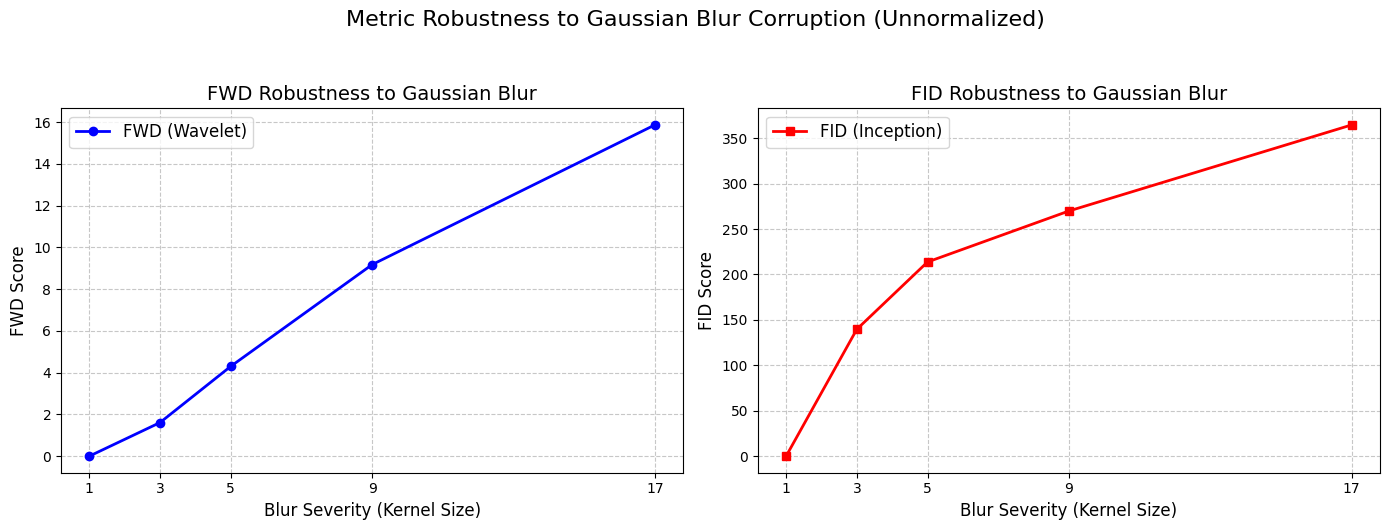

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FWD scores
axes[0].plot(blur_levels, fwd_scores, label='FWD (Wavelet)', marker='o', color='blue', linewidth=2)
axes[0].set_title('FWD Robustness to Gaussian Blur', fontsize=14)
axes[0].set_xlabel('Blur Severity (Kernel Size)', fontsize=12)
axes[0].set_ylabel('FWD Score', fontsize=12)
axes[0].set_xticks(blur_levels)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(fontsize=12)

# FID scores
axes[1].plot(blur_levels, fid_scores, label='FID (Inception)', marker='s', color='red', linewidth=2)
axes[1].set_title('FID Robustness to Gaussian Blur', fontsize=14)
axes[1].set_xlabel('Blur Severity (Kernel Size)', fontsize=12)
axes[1].set_ylabel('FID Score', fontsize=12)
axes[1].set_xticks(blur_levels)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(fontsize=12)

fig.suptitle('Metric Robustness to Gaussian Blur Corruption (Unnormalized)', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()